# N-Grams

It's a probabilistic model that's trained on a corpus of text. Such a model is useful in many NLP applications including speech recognition, machine translation and predictive text input. An N-gram model is built by counting how often word sequences occur in corpus text and then estimating the probabilities.

## Types of N-Grams

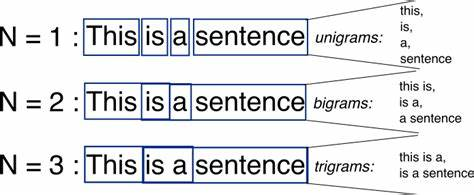

## Use-cases of N-Grams

- Auto completion of sentences
- Auto spell check
- Voice-based personal assistant bots

## Unigram

**Unigram** is an n-gram consisting of a single item of a sequence.

- It is commonly used to calculate the probability of finding a word in an article.

$$
P(A) = \frac{\text{count of } A}{\text{count of all words}}
$$

In [48]:
import nltk
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

unigrams = ngrams(word_tokenize(string), 1)

for item in unigrams:
    print(item)

('moses',)
('supposes',)
('his',)
('toeses',)
('are',)
('roses',)
('but',)
('moses',)
('supposes',)
('erroneously',)


### Calculating probabilities in unigram models

In [49]:
### Calculate counts of each word

unique_string = set(word_tokenize(string))

words_frq = []
for uniques in unique_string:
    frq = string.count(uniques)
    words_frq.append((uniques, frq))

words_frq

[('supposes', 2),
 ('erroneously', 1),
 ('toeses', 1),
 ('roses', 1),
 ('moses', 2),
 ('are', 1),
 ('his', 1),
 ('but', 1)]

In [50]:
### Calculate probabilities:

probab = []

for count in range(len(words_frq)):
    pro = words_frq[count][1]/len(word_tokenize(string))
    probab.append((words_frq[count][0],pro))

print('The probabilities are: ', probab)

The probabilities are:  [('supposes', 0.2), ('erroneously', 0.1), ('toeses', 0.1), ('roses', 0.1), ('moses', 0.2), ('are', 0.1), ('his', 0.1), ('but', 0.1)]


## Bigram

**Bigram** an n-gram consisting of two items of a sequence
- Two words that are used together to mean something specific

$$
P(B \mid A) = \frac{\text{Count of }(AB)}{\text{Count of }(A)}
$$

### Method 1

In [51]:
import nltk
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

bigrams = nltk.bigrams(word_tokenize(string))
for i in bigrams:
    print(i)


('moses', 'supposes')
('supposes', 'his')
('his', 'toeses')
('toeses', 'are')
('are', 'roses')
('roses', 'but')
('but', 'moses')
('moses', 'supposes')
('supposes', 'erroneously')


### Method 2

In [52]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

bigrams = ngrams(word_tokenize(string),2)

for i in bigrams:
    print(i)

('moses', 'supposes')
('supposes', 'his')
('his', 'toeses')
('toeses', 'are')
('are', 'roses')
('roses', 'but')
('but', 'moses')
('moses', 'supposes')
('supposes', 'erroneously')


# Trigram

**Trigram** an n-gram consisting of three items of a sequence
- Three words that are used together to mean something specific

### Method 1

In [53]:
import nltk
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

trigrams = nltk.trigrams(word_tokenize(string))

for i in trigrams:
    print(i)


('moses', 'supposes', 'his')
('supposes', 'his', 'toeses')
('his', 'toeses', 'are')
('toeses', 'are', 'roses')
('are', 'roses', 'but')
('roses', 'but', 'moses')
('but', 'moses', 'supposes')
('moses', 'supposes', 'erroneously')


### Method 2

In [54]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

trigrams = ngrams(word_tokenize(string),3)

for i in trigrams:
    print(i)


('moses', 'supposes', 'his')
('supposes', 'his', 'toeses')
('his', 'toeses', 'are')
('toeses', 'are', 'roses')
('are', 'roses', 'but')
('roses', 'but', 'moses')
('but', 'moses', 'supposes')
('moses', 'supposes', 'erroneously')


## What is padding in NLP?

Padding is a technique used to ensure that all input sequences have the same length. This is necessary because neural networks require inputs that have the same shape and size. However, when we pre-process and use texts as inputs for our model, not all sentences have the same length. In other words, some sentences are longer or shorter than others. We need to have inputs with the same size, and this is where padding comes in.

Padding is a special form of masking where the masked steps are at the start or the end of a sequence. Padding comes from the need to encode sequence data into contiguous batches: in order to make all sequences in a batch fit a given standard length.
The padding is added before splitting the sentence.

**n-1 padding is added.**



In [55]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize


string = "moses supposes his toeses are roses but moses supposes erroneously"

print('------------------- Padding in Bigrams ------------------------------')
list(ngrams(word_tokenize(string), pad_left=True, left_pad_symbol="<s>",
                                pad_right=True, right_pad_symbol="</s>", n=2))

------------------- Padding in Bigrams ------------------------------


[('<s>', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'his'),
 ('his', 'toeses'),
 ('toeses', 'are'),
 ('are', 'roses'),
 ('roses', 'but'),
 ('but', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'erroneously'),
 ('erroneously', '</s>')]

In [56]:
print('------------------- Padding in Trigrams ------------------------------')
list(ngrams(word_tokenize(string), pad_left=True, left_pad_symbol="<s>",
                                pad_right=True, right_pad_symbol="</s>", n=3))

------------------- Padding in Trigrams ------------------------------


[('<s>', '<s>', 'moses'),
 ('<s>', 'moses', 'supposes'),
 ('moses', 'supposes', 'his'),
 ('supposes', 'his', 'toeses'),
 ('his', 'toeses', 'are'),
 ('toeses', 'are', 'roses'),
 ('are', 'roses', 'but'),
 ('roses', 'but', 'moses'),
 ('but', 'moses', 'supposes'),
 ('moses', 'supposes', 'erroneously'),
 ('supposes', 'erroneously', '</s>'),
 ('erroneously', '</s>', '</s>')]

Alternatively, We can get rid of the parameters by using
> pad_both_ends method in NLTK

**Note the n argument, that tells the function we need padding for bigrams.**

In [57]:
from nltk.lm.preprocessing import pad_both_ends
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

string = "moses supposes his toeses are roses but moses supposes erroneously"

list(ngrams(pad_both_ends(word_tokenize(string), n=2), n=2))


[('<s>', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'his'),
 ('his', 'toeses'),
 ('toeses', 'are'),
 ('are', 'roses'),
 ('roses', 'but'),
 ('but', 'moses'),
 ('moses', 'supposes'),
 ('supposes', 'erroneously'),
 ('erroneously', '</s>')]

### Training the Maximum Likelihood Model

Maximum likelihood estimation estimates the model parameters such that the probability is maximized.

- Get the requisite n_grams frequency counts from a corpus.

- Normalize them to a 0-1 range.


- Build the vocabulary (of unique words): to create this vocabulary we need to pad our sentences (just like for counting ngrams) and then combine the sentences into one flat stream of words.


To do the above steps, we need to create an Ngram and add the padding then flatten the list. All these steps are requested for pre-processing to train the MLE model. However, we can use padded_everygram_pipeline() in NLTK to do all the steps in one call.

The  padded_everygram_pipeline() will return:  
1- **ngrams_gen:** Each sentence becomes a list of n-grams with padding.  
2- **vocab_gen:** A flat stream of all tokens, with start and end symbols included  

**References:**

https://www.nltk.org/api/nltk.lm.html

https://www.kaggle.com/code/alvations/n-gram-language-model-with-nltk

In [58]:
from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
from nltk.lm import smoothing

string = "moses supposes his toeses are roses but moses supposes erroneously"

#Create Bigram Language Model
train, vocab = padded_everygram_pipeline(2, [word_tokenize(string)])

In [59]:
from nltk.lm import MLE
lm = MLE(2)
lm.fit(train, vocab) #Train the Maximum Likelihood Model

### Calculating Probabilities
Here’s how you get the score for a word given some preceding context. For example we want to know what is the chance that “b” is preceded by “a”.

In [60]:
print(lm.score('supposes', ['moses'])) #Calculate Bigram Probabilities for P('moses'|'supposes')
print(lm.score('moses', ['supposes'])) #Calculate Bigram Probabilities for P('supposes'|'moses') - Returns 0 because unseen

1.0
0.0


### Evaluating n_grams models using preplexity

**Preplexity** is a measurement of how well a probability model (like a language model) predicts a sample.

It's the probability of the test set normalized by the number of words.

A `lower` perplexity means:

- The model is less “perplexed” by the data.

- The model assigns higher probabilities to the actual words in the test set.

- Therefore, better performance.

A `higher perplexity` = more uncertainty = worse model.

In [61]:
test = [('moses', 'supposes'), ('toeses','are')]
print(lm.perplexity(test)) #Perplexity for bigram model

1.0


## Task: Generating tweets using n_grams

In this Task, we will build a MLE model with n-gram to generate tweets.

The agenda is:
1. load the data:
https://www.kaggle.com/datasets/adizafar/large-random-tweets-from-pakistan

2. pre-processing the data:
*   Remove hashtags
*   Remove RT
*   Remove any website
*   Remove any mentions
*   Remove emojis


3. build MLE model with n-gram (Bi-gram)
4. evaluate the model
5. calculate the probability of the bigram: (pakistan is)
6. calculate the preplexity of the word: (pakistan)

before we start we need to install library to handle the emojis in tweets
> pip install emoji

### Solution - Lab Way

The following solution uses the same NLTK ideas/functions introduced in the lab.


In [62]:
!pip install emoji


In [64]:
import pandas as pd

data = pd.read_csv('Random Tweets from Pakistan-Cleaned-Anonymous.csv', encoding='latin1')
data.head()


C:\Users\Huawei\AppData\Local\Temp\ipykernel_7624\1820325148.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('Random Tweets from Pakistan-Cleaned-Anonymous.csv', encoding='latin1')


,Unnamed: 0,created_at_tweet,full_text,retweet_count,favorite_count,reply_count,location
0,0,Wed Jul 03 07:20:15 +0000 2019,ØªÛØ±Ø§ ÙÛÚØ± Ù ÛØ±Ø§ ÙÛÚØ± ÙÙØ§Ø² Ø...,226,1097,127,"Punjab, Pakistan"
1,1,Fri Jul 02 02:50:53 +0000 2021,"Happy birthday to my brother n boss , May you ...",54,273,9,"Punjab, Pakistan"
2,2,Fri Jul 02 12:12:53 +0000 2021,â¤ï¸â¤ï¸,50,131,13,"Punjab, Pakistan"
3,3,Tue Oct 15 22:29:16 +0000 2019,`suspicious Â°jikook au jimin'in yaÅadÄ±ÄÄ± ...,522,2134,86,"Ä°stanbul, TÃ¼rkiye"
4,4,Wed May 13 04:34:31 +0000 2020,Speaking of @SpiderMan... ð https://t.co/...,74,535,11,Follow the ATP Tour â¡


In [65]:
data.columns


Index(['Unnamed: 0', 'created_at_tweet', 'full_text', 'retweet_count',
       'favorite_count', 'reply_count', 'location'],
      dtype='object')

In [66]:
import re
import emoji

def clean_tweet(tweet):
    tweet = str(tweet).lower()
    tweet = re.sub(r'#\w+', '', tweet)              
    tweet = re.sub(r'\brt\b', '', tweet)         
    tweet = re.sub(r'http\S+|www\.\S+', '', tweet) 
    tweet = re.sub(r'@\w+', '', tweet)              
    tweet = emoji.replace_emoji(tweet, replace='')   
    return tweet

data['clean_tweet'] = data['full_text'].apply(clean_tweet)
data[['full_text', 'clean_tweet']].head()


,full_text,clean_tweet
0,ØªÛØ±Ø§ ÙÛÚØ± Ù ÛØ±Ø§ ÙÛÚØ± ÙÙØ§Ø² Ø...,øªûø±ø§ ùûúø± ù ûø±ø§ ùûúø± ùùø§ø² ø...
1,"Happy birthday to my brother n boss , May you ...","happy birthday to my brother n boss , may you ..."
2,â¤ï¸â¤ï¸,â¤ï¸â¤ï¸
3,`suspicious Â°jikook au jimin'in yaÅadÄ±ÄÄ± ...,`suspicious â°jikook au jimin'in yaåadä±ää± ...
4,Speaking of @SpiderMan... ð https://t.co/...,speaking of ... ð


In [67]:
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

tokenized_tweets = []

for tweet in data['clean_tweet']:
    tokenized_tweets.append(word_tokenize(tweet))

tokenized_tweets[:5]


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Huawei\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Huawei\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


[['øªû\x8cø±ø§',
  'ù\x84û\x8cú\x88ø±',
  'ù',
  'û\x8cø±ø§',
  'ù\x84û\x8cú\x88ø±',
  'ù\x86ù\x88ø§ø²',
  'ø´ø±û\x8cù\x81',
  'ù\x86ù\x88ø§ø²',
  'ø´ø±û\x8cù\x81â\x9d¤ï¸\x8f',
  'úû\x8cø§',
  'ø¢ù¾úø§',
  'ø¨ú¾û\x8c',
  'ú¾û\x92ø\x9fø\x9fø\x9f'],
 ['happy',
  'birthday',
  'to',
  'my',
  'brother',
  'n',
  'boss',
  ',',
  'may',
  'you',
  'have',
  'many',
  'many',
  'moreð\x9f\x8e\x82ð\x9f\x8e\x82ð\x9f\x8e\x82',
  ',',
  'you',
  'are',
  'gem',
  'ð\x9f\x92\x8e'],
 ['â\x9d¤ï¸\x8fâ\x9d¤ï¸\x8f'],
 ['`',
  'suspicious',
  'â°jikook',
  'au',
  "jimin'in",
  'yaå\x9fadä±ä\x9fä±',
  'kasabada',
  'aniden',
  'baå\x9flayan',
  'cinayetler',
  ',',
  'onun',
  'kendisini',
  'sã¼rekli',
  'takip',
  'eden',
  'yeni',
  'komå\x9fusu',
  "jungkook'tan",
  'å\x9fã¼phelenmesine',
  'neden',
  'olur'],
 ['speaking', 'of', '...', 'ð\x9f\x98\x82']]

In [68]:
from nltk.lm.preprocessing import padded_everygram_pipeline
from nltk.lm import MLE

train, vocab = padded_everygram_pipeline(2, tokenized_tweets)

lm = MLE(2)
lm.fit(train, vocab)


In [69]:
from nltk.util import ngrams

test = list(ngrams(tokenized_tweets[0], 2))
print('Model perplexity:', lm.perplexity(test))


Model perplexity: 85.38777234366802


In [70]:
print('P(is | pakistan) =', lm.score('is', ['pakistan']))


P(is | pakistan) = 0.05107424114993501


In [71]:
test_word = [('pakistan',)]
print('Perplexity of pakistan =', lm.perplexity(test_word))


Perplexity of pakistan = 305.97843871855645
